In [2]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import random
import albumentations as A
from torchvision import transforms
import cv2
from torch import Tensor

# Task 1

Python class for initializing and accessing the contents of the CT dataset

In [3]:
class RSNADataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        raw_df = pd.read_csv(csv_file)
        
        temp_split = raw_df['ID'].str.rsplit('_', n=1, expand=True)
        raw_df['ImageID'] = temp_split[0]
        raw_df['DiagnosisType'] = temp_split[1]
        
        self.data = raw_df.pivot(index='ImageID', columns='DiagnosisType', values='Label').reset_index()
        
        self.target_cols = [
            'epidural', 'intraparenchymal', 'intraventricular', 
            'subarachnoid', 'subdural', 'any'
        ]
        
        for col in self.target_cols:
            if col not in self.data.columns:
                self.data[col] = 0
                
        self.data = self.data[['ImageID'] + self.target_cols]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # if torch.is_tensor(idx):
        #     idx = idx.tolist()

        row = self.data.iloc[idx]
        img_id = row['ImageID']
        
        labels = torch.tensor(row[self.target_cols].values.astype('float32'))

        img_filename = f"{img_id}_frame0.png"
        img_path = os.path.join(self.root_dir, img_filename)

        # Incarcare LAZY a imaginii
        try:
            image = Image.open(img_path) 
        except FileNotFoundError:
            print(f"Imagine lipsa: {img_path}")
            print(img_path)
            image = Image.new('RGB', (256, 256))
        
        if self.transform:
            image = self.transform(image)

        return image, labels

# Task 2

Function for train-validation split

In [4]:
def get_train_val_split(dataset, val_size=0.2, random_state=42, train_transforms=None, val_transforms=None):
    
    if hasattr(dataset, 'data'):
        stratify_labels = dataset.data['any'].values
    else:
        stratify_labels = None
        print("Atentie: Nu s-au gasit etichete pentru stratificare. Se va face split aleatoriu.")

    train_idx, val_idx = train_test_split(
        np.arange(len(dataset)),
        test_size=val_size,
        random_state=random_state,
        shuffle=True,
        stratify=stratify_labels
    )

    train_dataset = RSNADataset(
        csv_file='/kaggle/input/rsna-hemorrhage-detection-dataset/subdataset_train.csv', 
        root_dir='/',
        transform=train_transforms  # Pipeline-ul complex definit anterior
    )
    
    val_dataset = RSNADataset(
        csv_file='/kaggle/input/rsna-hemorrhage-detection-dataset/subdataset_train.csv', 
        root_dir='/',
        transform=val_transforms     # Pipeline-ul simplu (Clean)
    )
    
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(val_dataset, val_idx)

    return train_subset, val_subset

# Task 3

Functions for plotting class distribution

In [5]:
def get_counts_from_dataset(dataset_obj):
    
    target_cols = ['epidural', 'intraparenchymal', 'intraventricular', 
                   'subarachnoid', 'subdural', 'any']
    
    if isinstance(dataset_obj, Subset):
        parent_dataset = dataset_obj.dataset
        subset_df = parent_dataset.data.iloc[dataset_obj.indices]
        counts = subset_df[target_cols].sum()
        total_samples = len(subset_df)
        
    else:
        counts = dataset_obj.data[target_cols].sum()
        total_samples = len(dataset_obj)
        
    return counts, total_samples

def plot_distributions(train_set, val_set, test_set):
    sets = {
        "Antrenare (Train)": train_set,
        "Validare (Val)": val_set,
        "Testare (Test)": test_set
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
    colors = sns.color_palette("viridis", 6)
    
    results = {}

    for ax, (name, dataset) in zip(axes, sets.items()):
        counts, total = get_counts_from_dataset(dataset)
        results[name] = counts # Salvam pentru raport
        
        percentages = (counts / total) * 100
        
        sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=colors)
        
        ax.set_title(f"Distributie: {name}\n(Total imagini: {total})")
        ax.set_ylabel("Numar imagini pozitive")
        ax.set_xticklabels(counts.index, rotation=45)
        
        for i, v in enumerate(counts.values):
            ax.text(i, v + (v * 0.05), f"{int(v)}\n({percentages[i]:.1f}%)", 
                    ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()
    return results

Displaying distribution graphs

/tmp/ipykernel_47/1674375099.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + (v * 0.05), f"{int(v)}\n({percentages[i]:.1f}%)",
/tmp/ipykernel_47/1674375099.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + (v * 0.05), f"{int(v)}\n({percentages[i]:.1f}%)",
/tmp/ipykernel_47/1674375099.py:57: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + (v * 0.05), f"{int(v)}\n({percentages[i]:.1f}

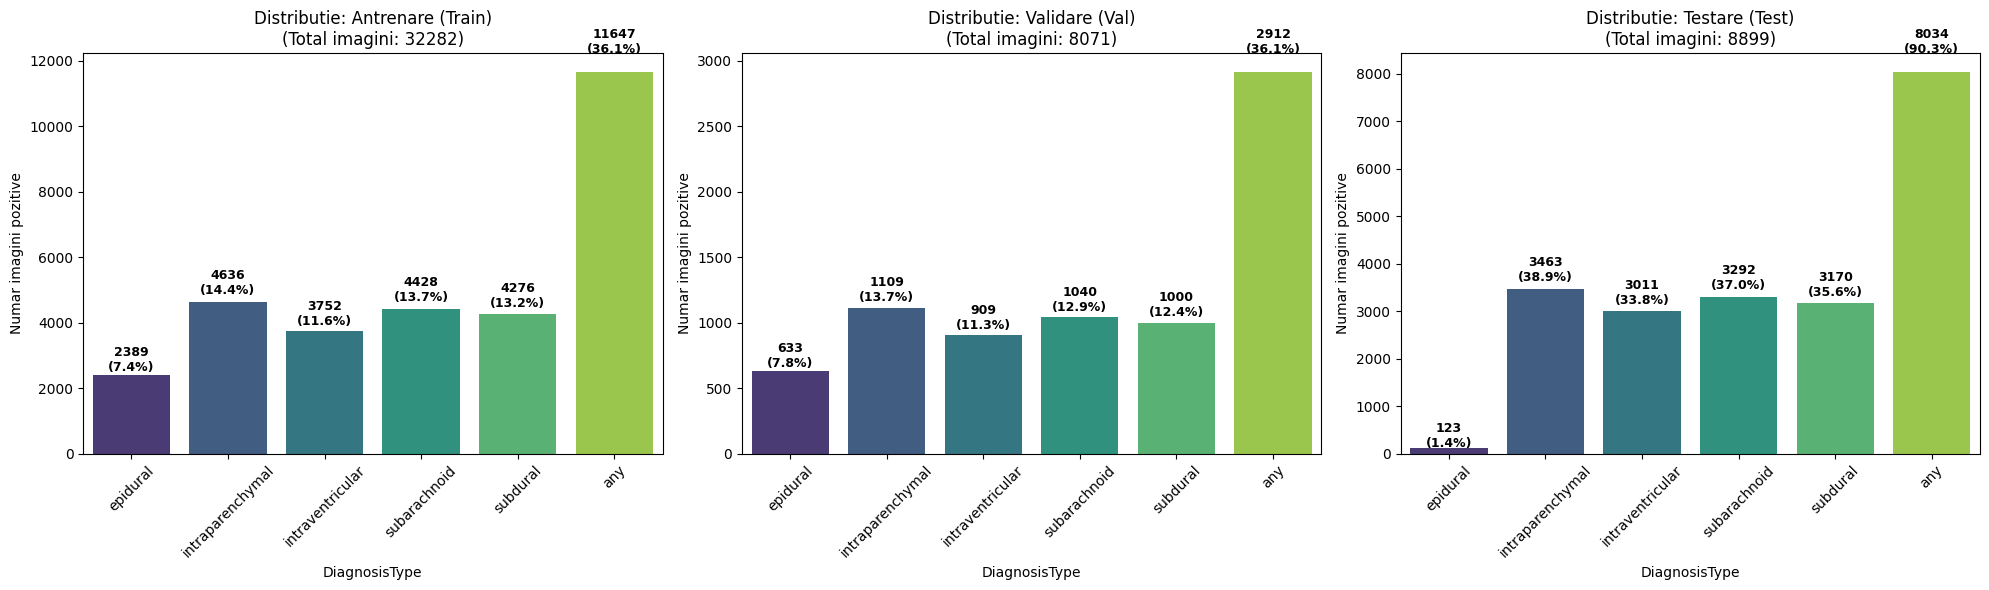

In [6]:
full_train_dataset = RSNADataset(csv_file='/kaggle/input/rsna-hemorrhage-detection-dataset/subdataset_train.csv', root_dir='/kaggle/input/rsna-hemorrhage-detection-dataset/rsna-intracranial-hemorrhage-detection-png/train_images')
test_dataset = RSNADataset(csv_file='/kaggle/input/rsna-hemorrhage-detection-dataset/subdataset_test.csv', root_dir='/kaggle/input/rsna-hemorrhage-detection-dataset/rsna-intracranial-hemorrhage-detection-png/test_images')

train_subset, val_subset = get_train_val_split(full_train_dataset, val_size=0.2)

stats = plot_distributions(train_subset, val_subset, test_dataset)

# Task 4

Visualizing examples from each hemorrhage category present in the dataset

Scanez primele 1000 imagini pentru cazuri strict exclusive...
Categoria 'Healthy': gasite 647, afisez 7
Categoria 'epidural': gasite 45, afisez 7
Categoria 'intraparenchymal': gasite 37, afisez 7
Categoria 'intraventricular': gasite 27, afisez 7
Categoria 'subarachnoid': gasite 27, afisez 7
Categoria 'subdural': gasite 35, afisez 7


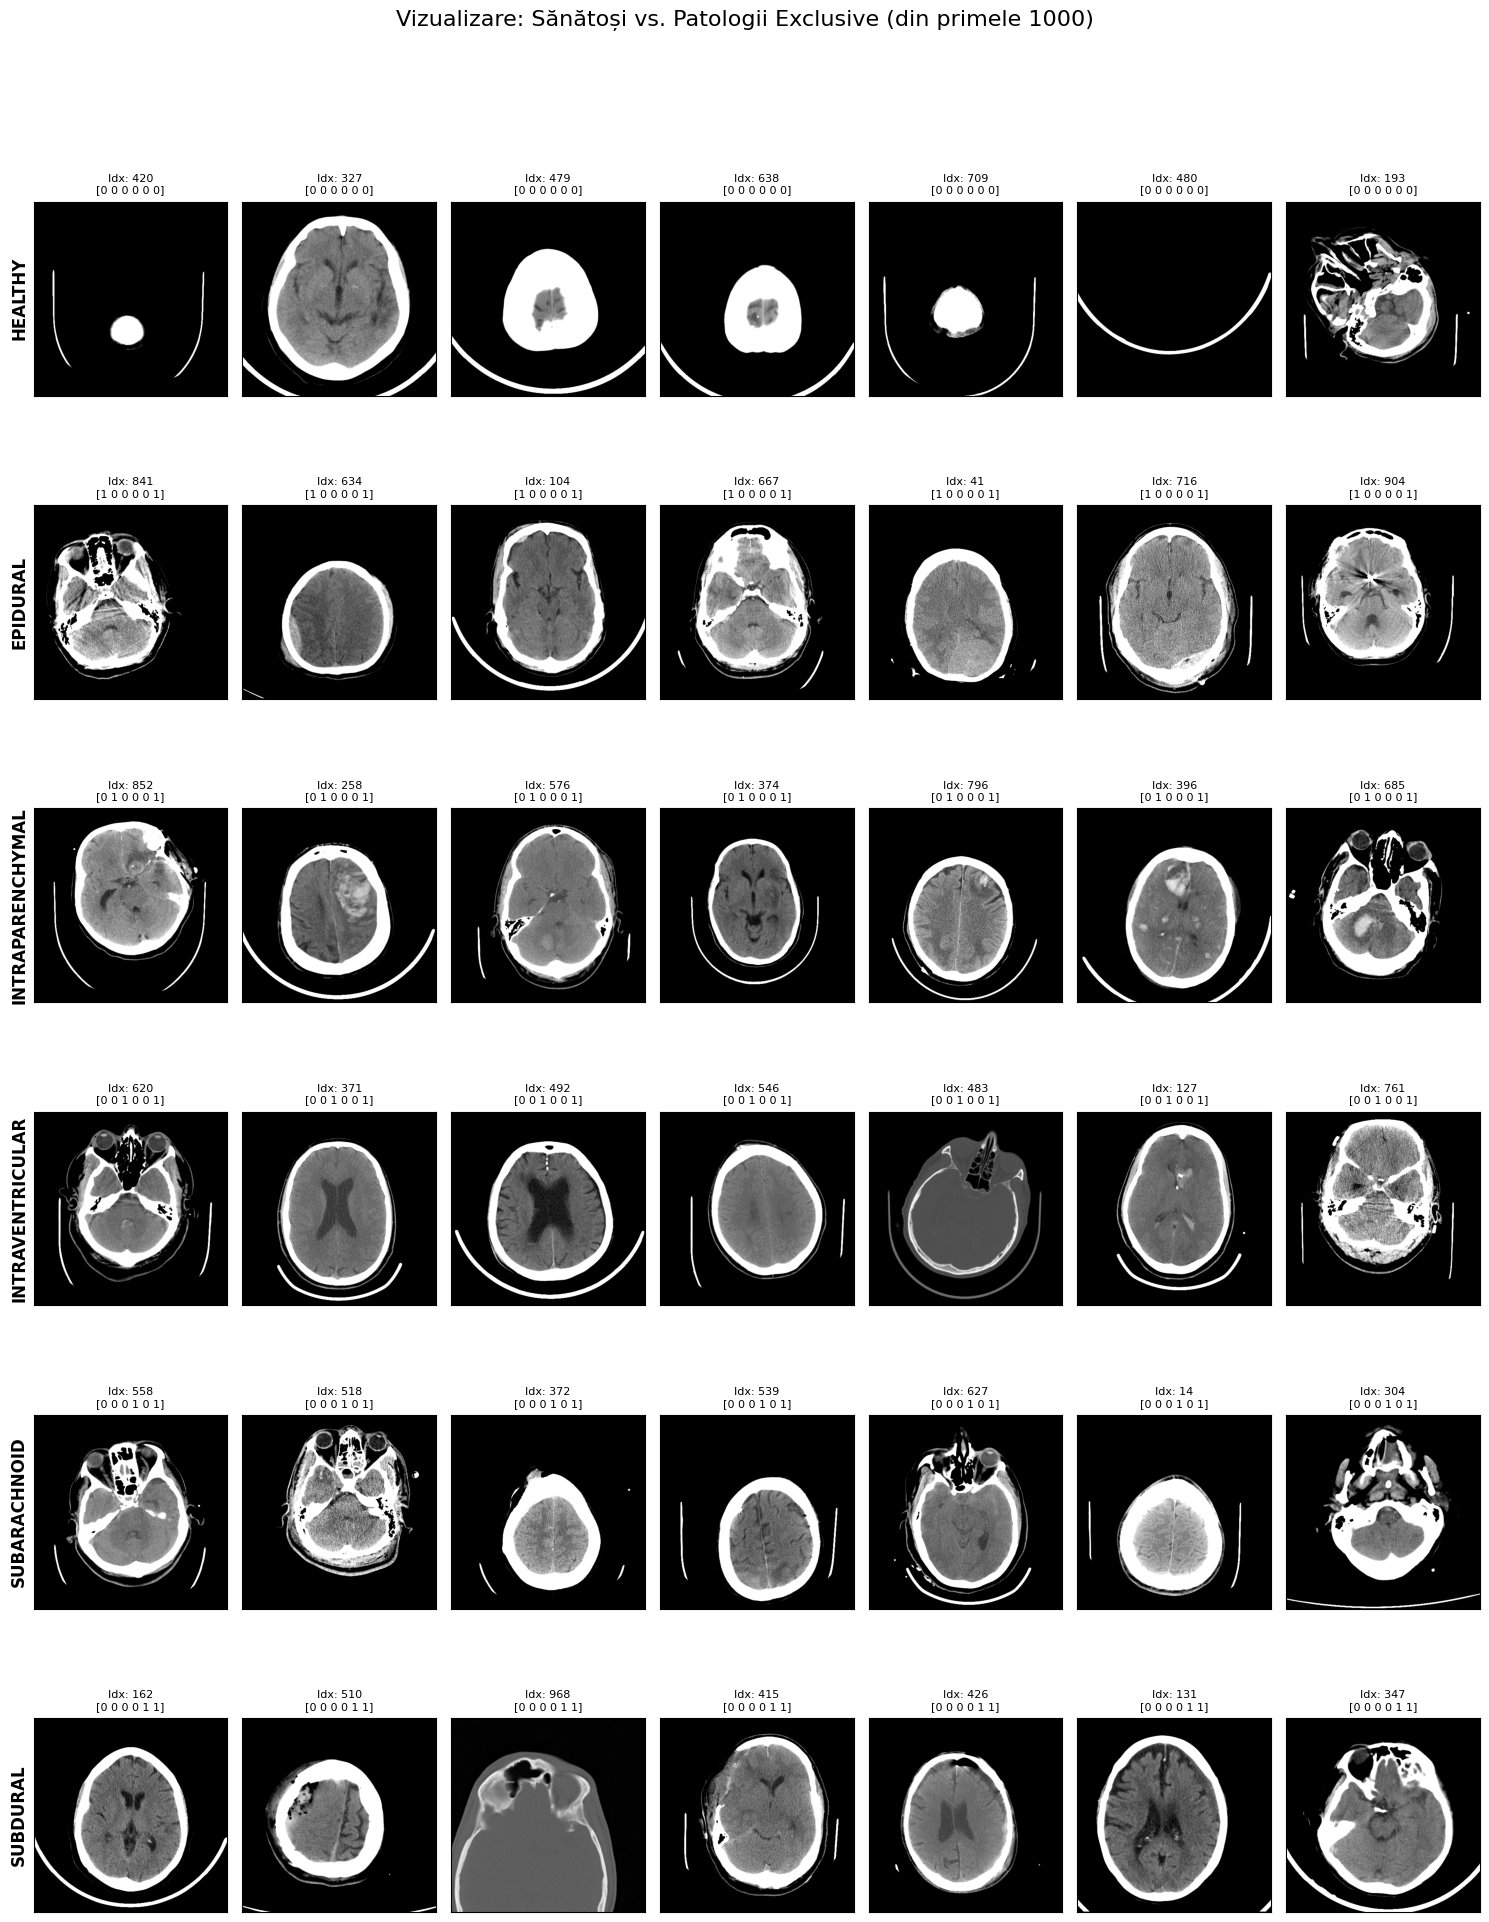

In [7]:
def visualize_hemorrhage_types(dataset, search_limit=1000, num_samples=5):
    
    specific_types = ['epidural', 'intraparenchymal', 'intraventricular', 
                      'subarachnoid', 'subdural']
    all_cols = specific_types + ['any']
    
    display_categories = ['Healthy'] + specific_types
    
    candidates = {cat: [] for cat in display_categories}
    
    print(f"Scanez primele {search_limit} imagini pentru cazuri strict exclusive...")
    subset_df = dataset.data.iloc[:search_limit]
    
    for idx, row in subset_df.iterrows():
        vector = row[all_cols].values.astype(int)
        
        specific_part = vector[:5] # Primele 5 elemente (tipurile)
        any_flag = vector[5]       # Ultimul element (Any)
        
        
        if any_flag == 0 and np.sum(specific_part) == 0:
            candidates['Healthy'].append(idx)
            
        elif any_flag == 1 and np.sum(specific_part) == 1:
            active_index = np.argmax(specific_part)
            active_name = specific_types[active_index]
            candidates[active_name].append(idx)

    
    rows = len(display_categories) 
    cols = num_samples             
    
    fig = plt.figure(figsize=(15, 3.5 * rows))
    plt.suptitle(f"Vizualizare: Sănătoși vs. Patologii Exclusive (din primele {search_limit})", fontsize=16)
    
    plot_idx = 1
    
    for cat in display_categories:
        available_indices = candidates[cat]
        count_found = len(available_indices)
        
        if count_found >= num_samples:
            selected_indices = random.sample(available_indices, num_samples)
        else:
            selected_indices = available_indices
            
        print(f"Categoria '{cat}': gasite {count_found}, afisez {len(selected_indices)}")

        if not selected_indices:
            for _ in range(num_samples):
                ax = fig.add_subplot(rows, cols, plot_idx)
                ax.text(0.5, 0.5, "Niciun exemplu\ngăsit", ha='center', va='center')
                if _ == 0: ax.set_ylabel(cat.upper(), fontsize=12, fontweight='bold')
                ax.axis('off')
                plot_idx += 1
            continue

        for i, img_idx in enumerate(selected_indices):
            ax = fig.add_subplot(rows, cols, plot_idx)
            
            img_tensor, label_tensor = dataset[img_idx]
            
            img_np = np.array(img_tensor)
            # if img_np.shape[0] == 1:
            #     img_np = img_np.squeeze()
            #     cmap = 'gray'
            # else:
            #     img_np = np.transpose(img_np, (1, 2, 0))
            #     cmap = None

            if len(img_np.shape) == 2: # E grayscale (H, W)
                cmap = 'gray'
            else:
                cmap = None
            
            ax.imshow(img_np, cmap=cmap)
            
            if i == 0:
                ax.set_ylabel(cat.upper(), fontsize=12, fontweight='bold')
            
            lbls = label_tensor.numpy().astype(int)
            ax.set_title(f"Idx: {img_idx}\n{lbls}", fontsize=8)
            
            ax.set_xticks([])
            ax.set_yticks([])
            
            plot_idx += 1
            
        if len(selected_indices) < num_samples:
             for _ in range(num_samples - len(selected_indices)):
                ax = fig.add_subplot(rows, cols, plot_idx)
                ax.axis('off')
                plot_idx += 1

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("type_comparison.png")
    plt.show()

visualize_hemorrhage_types(full_train_dataset, num_samples=7)

# Task 5

Number of channels (greyscale vs. RGB) of dataset images

In [2]:
from PIL import Image
from tqdm import tqdm

def analyze_and_plot_channels(dataset):
    
    counts = {
        '1 Canal (Grayscale)': 0,
        '3 Canale (RGB)': 0,
        '4 Canale (RGBA)': 0,
        'Altele': 0
    }
    
    print(f"Analizez {len(dataset)} imagini accesand dataset-ul...")
    
    for i in tqdm(range(len(dataset))):
        try:
            img, _ = dataset[i]
            num_channels = 0
            
            if isinstance(img, Image.Image):
                if img.mode == 'L':
                    num_channels = 1
                elif img.mode == 'RGB':
                    num_channels = 3
                elif img.mode == 'RGBA':
                    num_channels = 4
                else:
                    num_channels = -1 # Altele
            
            elif isinstance(img, torch.Tensor):
                num_channels = img.shape[0]
                
            elif isinstance(img, np.ndarray):
                if len(img.shape) == 2:
                    num_channels = 1
                elif len(img.shape) == 3:
                    num_channels = min(img.shape) if min(img.shape) <= 4 else 1

            if num_channels == 1:
                counts['1 Canal (Grayscale)'] += 1
            elif num_channels == 3:
                counts['3 Canale (RGB)'] += 1
            elif num_channels == 4:
                counts['4 Canale (RGBA)'] += 1
            else:
                counts['Altele'] += 1
                
        except Exception as e:
            print(f"Eroare la indexul {i}: {e}")
            continue

    
    labels = [k for k, v in counts.items() if v > 0]
    values = [v for v in counts.values() if v > 0]
    
    if not labels:
        print("Nu s-au putut determina canalele.")
        return

    plt.figure(figsize=(5, 6))
    bars = plt.bar(labels, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    
    plt.title(f'Distribuția Nr. de Canale (Analizată prin Dataset)\nTotal: {sum(values)}', fontsize=14)
    plt.ylabel('Număr Imagini', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    total = sum(values)
    for bar in bars:
        height = bar.get_height()
        pct = (height / total) * 100
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
                 
    plt.tight_layout()
    plt.show()
    return counts

Setul de date de antrenare:

Analizez 40353 imagini accesand dataset-ul...


100%|██████████| 40353/40353 [02:42<00:00, 248.18it/s]


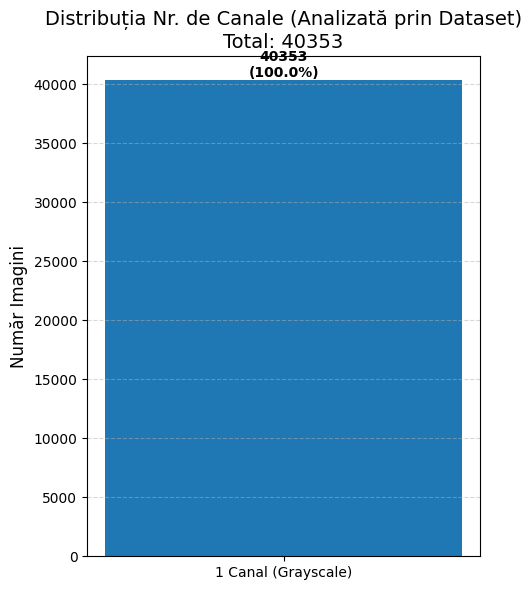

Statistici detaliate: {'1 Canal (Grayscale)': 40353, '3 Canale (RGB)': 0, '4 Canale (RGBA)': 0, 'Altele': 0}


In [3]:
stats = analyze_and_plot_channels(full_train_dataset)
print("Statistici detaliate:", stats)

Setul de date de testare

Analizez 8899 imagini accesand dataset-ul...


100%|██████████| 8899/8899 [01:47<00:00, 82.82it/s]


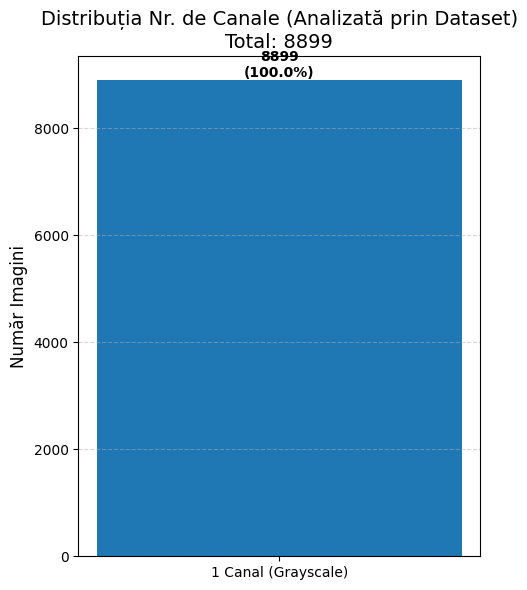

Statistici detaliate: {'1 Canal (Grayscale)': 8899, '3 Canale (RGB)': 0, '4 Canale (RGBA)': 0, 'Altele': 0}


In [4]:
stats = analyze_and_plot_channels(test_dataset)
print("Statistici detaliate:", stats)

Analysis of the variety of image sizes in the training dataset:

Verific dimensiunile pentru 40353 imagini accesand dataset-ul...


100%|██████████| 40353/40353 [07:05<00:00, 94.95it/s] 



Rezultat: Imaginile sunt Neuniforme.
 - Rezolutie 512x512: 40341 imagini
 - Rezolutie 404x430: 4 imagini
 - Rezolutie 464x464: 3 imagini
 - Rezolutie 374x408: 2 imagini
 - Rezolutie 490x638: 2 imagini
 - Rezolutie 512x666: 1 imagini


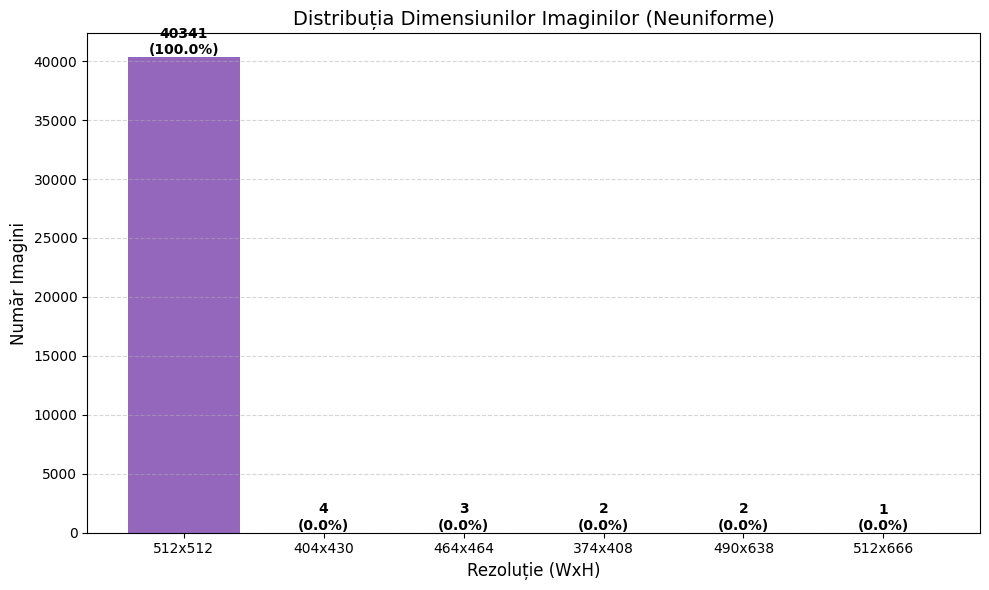

{'512x512': 40341,
 '464x464': 3,
 '404x430': 4,
 '512x666': 1,
 '374x408': 2,
 '490x638': 2}

In [1]:
def check_image_dimensions(dataset):
    
    dim_counts = {}
    
    print(f"Verific dimensiunile pentru {len(dataset)} imagini accesand dataset-ul...")
    
    for i in tqdm(range(len(dataset))):
        try:
            img, _ = dataset[i]
            
            width, height = 0, 0
            
            if isinstance(img, Image.Image):
                width, height = img.size # PIL returneaza (W, H)
                
            elif isinstance(img, torch.Tensor):
                height = img.shape[1]
                width = img.shape[2]
                
            elif isinstance(img, np.ndarray):
                height = img.shape[0]
                width = img.shape[1]
                
            res_key = f"{width}x{height}"
            
            if res_key in dim_counts:
                dim_counts[res_key] += 1
            else:
                dim_counts[res_key] = 1
                
        except Exception as e:
            print(f"Eroare la index {i}: {e}")
            continue

    
    sorted_dims = sorted(dim_counts.items(), key=lambda item: item[1], reverse=True)
    
    labels = [k for k, v in sorted_dims]
    values = [v for k, v in sorted_dims]
    
    if not labels:
        print("Nu s-au putut extrage dimensiunile.")
        return

    is_uniform = len(labels) == 1
    status_msg = "Uniforme" if is_uniform else "Neuniforme"
    print(f"\nRezultat: Imaginile sunt {status_msg}.")
    for res, count in sorted_dims:
        print(f" - Rezolutie {res}: {count} imagini")

    plt.figure(figsize=(10, 6))
    
    bars = plt.bar(labels, values, color='#9467bd')
    
    plt.title(f'Distribuția Dimensiunilor Imaginilor ({status_msg})', fontsize=14)
    plt.xlabel('Rezoluție (WxH)', fontsize=12)
    plt.ylabel('Număr Imagini', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    total = sum(values)
    for bar in bars:
        height = bar.get_height()
        pct = (height / total) * 100
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
                 
    plt.tight_layout()
    plt.show()
    
    return dim_counts

check_image_dimensions(full_train_dataset)

Analysis of the variety of image sizes in the test dataset:

Verific dimensiunile pentru 8899 imagini accesand dataset-ul...


100%|██████████| 8899/8899 [00:28<00:00, 309.69it/s]



Rezultat: Imaginile sunt Neuniforme.
 - Rezolutie 512x512: 8894 imagini
 - Rezolutie 462x462: 2 imagini
 - Rezolutie 490x638: 1 imagini
 - Rezolutie 404x430: 1 imagini
 - Rezolutie 768x768: 1 imagini


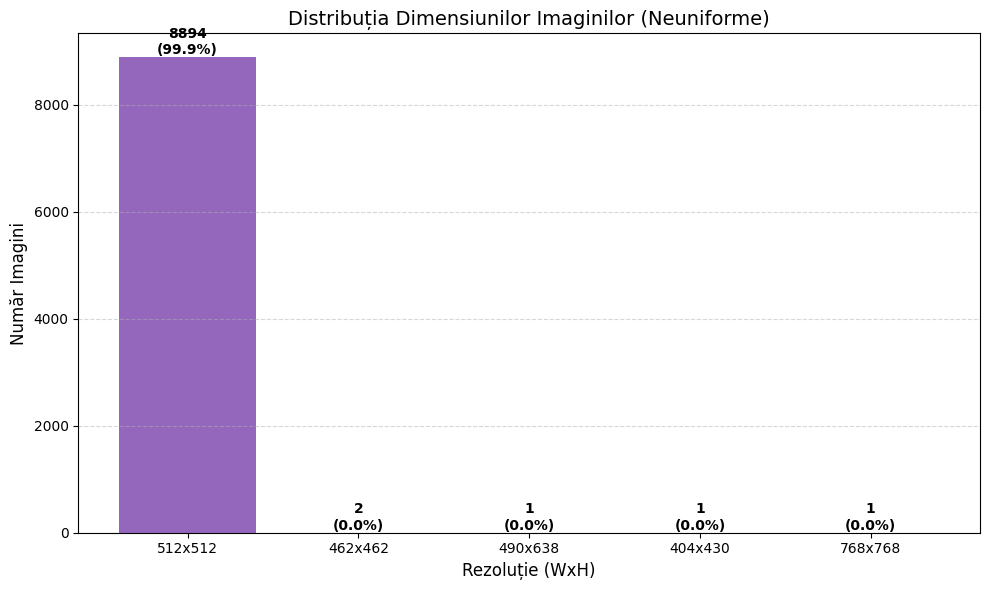

{'512x512': 8894, '490x638': 1, '404x430': 1, '768x768': 1, '462x462': 2}

In [5]:
check_image_dimensions(test_dataset)

Scaling range analysis for images in the dataset:

In [13]:
def check_pixel_values_and_stats(dataset):
    
    print(f"Verific integritatea pixelilor pentru TOT setul de date ({len(dataset)} imagini)...")
    
    global_min = float('inf')
    global_max = float('-inf')
    
    histogram_pixels = []
    sample_limit = 1000 
    
    for i in tqdm(range(len(dataset))):
        try:
            img_obj, _ = dataset[i]
            
            if isinstance(img_obj, torch.Tensor):
                img_arr = img_obj.numpy()
            elif isinstance(img_obj, Image.Image):
                img_arr = np.array(img_obj)
            else:
                img_arr = np.array(img_obj)

            current_min = np.min(img_arr)
            current_max = np.max(img_arr)
            
            if current_min < global_min: global_min = current_min
            if current_max > global_max: global_max = current_max
            
            if np.isnan(img_arr).any() or np.isinf(img_arr).any():
                print(f" ALERTA: Imagine corupta (NaN/Inf) la indexul {i}!")
            
            if i < sample_limit:
                img_flat = img_arr.flatten()
                
                if len(img_flat) > 1000:
                    sample = np.random.choice(img_flat, size=1000, replace=False)
                else:
                    sample = img_flat
                    
                histogram_pixels.append(sample)
                
        except Exception as e:
            print(f"Eroare la citirea imaginii {i}: {e}")

    print("\n--- Rezultate Verificare Completă (Original Data) ---")
    print(f"Minim Absolut găsit: {global_min}")
    print(f"Maxim Absolut găsit: {global_max}")
    
    if global_max > 1.0:
        print("(Nota: Valorile > 1 indica format 0-255, tipic pentru PNG/PIL inainte de ToTensor)")
    else:
        print("(Nota: Valorile <= 1 indica format normalizat 0-1, tipic pentru Tensor)")

    if histogram_pixels:
        all_pixels_sample = np.concatenate(histogram_pixels)
        mean_val = np.mean(all_pixels_sample)
        std_val = np.std(all_pixels_sample)
        
        plt.figure(figsize=(10, 6))
        bins = 256 if global_max > 1 else 50
        
        plt.hist(all_pixels_sample, bins=bins, color='teal', alpha=0.7, edgecolor='black')
        
        plt.title(f'Distribuția Intensității (Estimată pe primele {sample_limit} imagini)\nRaw Data (fara ToTensor)', fontsize=14)
        plt.xlabel('Valoare Pixel', fontsize=12)
        plt.ylabel('Frecvență (Log Scale)', fontsize=12)
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.5)
        
        plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_val:.2f}')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

Setul de date de antrenare:

Verific integritatea pixelilor pentru TOT setul de date (40353 imagini)...


100%|██████████| 40353/40353 [07:53<00:00, 85.25it/s]



--- Rezultate Verificare Completă (Original Data) ---
Minim Absolut găsit: 0
Maxim Absolut găsit: 255
(Nota: Valorile > 1 indica format 0-255, tipic pentru PNG/PIL inainte de ToTensor)


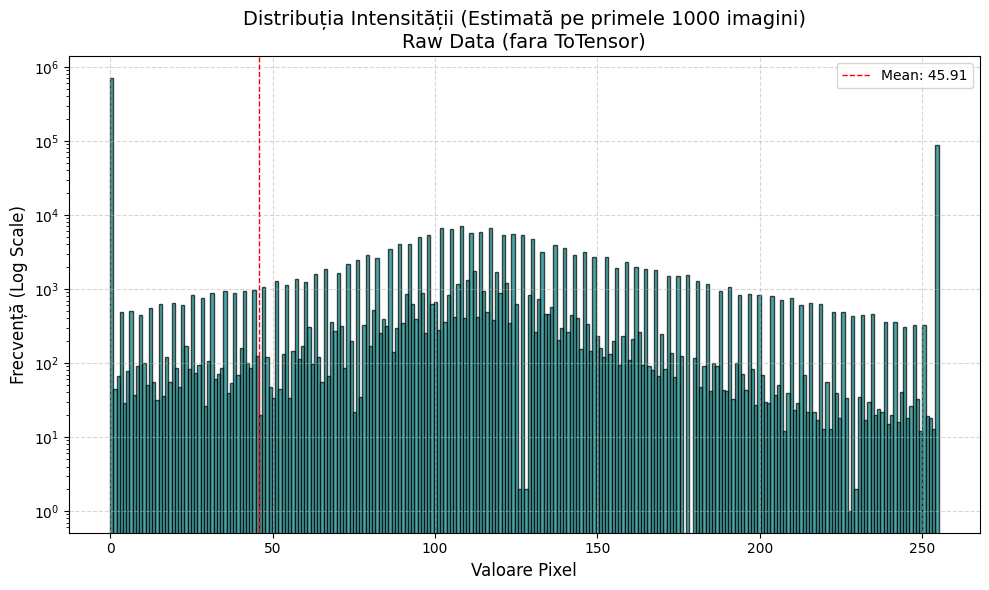

In [14]:
check_pixel_values_and_stats(full_train_dataset)

Setul de date de testare:

Verific integritatea pixelilor pentru TOT setul de date (8899 imagini)...


100%|██████████| 8899/8899 [01:46<00:00, 83.36it/s]



--- Rezultate Verificare Completă (Original Data) ---
Minim Absolut găsit: 0
Maxim Absolut găsit: 255
(Nota: Valorile > 1 indica format 0-255, tipic pentru PNG/PIL inainte de ToTensor)


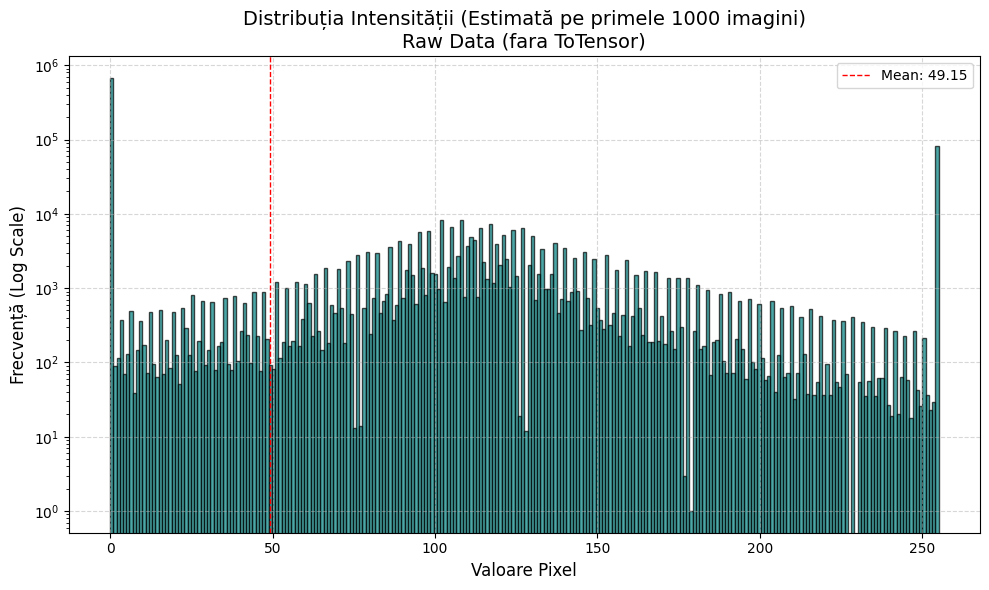

In [15]:
check_pixel_values_and_stats(test_dataset)

# Task 6

### Augmentations

- rescaling images to 256x256
- random flip/zoom/rotate for training dataset
- intensity normalization
- Gaussian Filter & CLAHE Filter
- standardization using median and standard deviation

## Gaussian Filter - examples

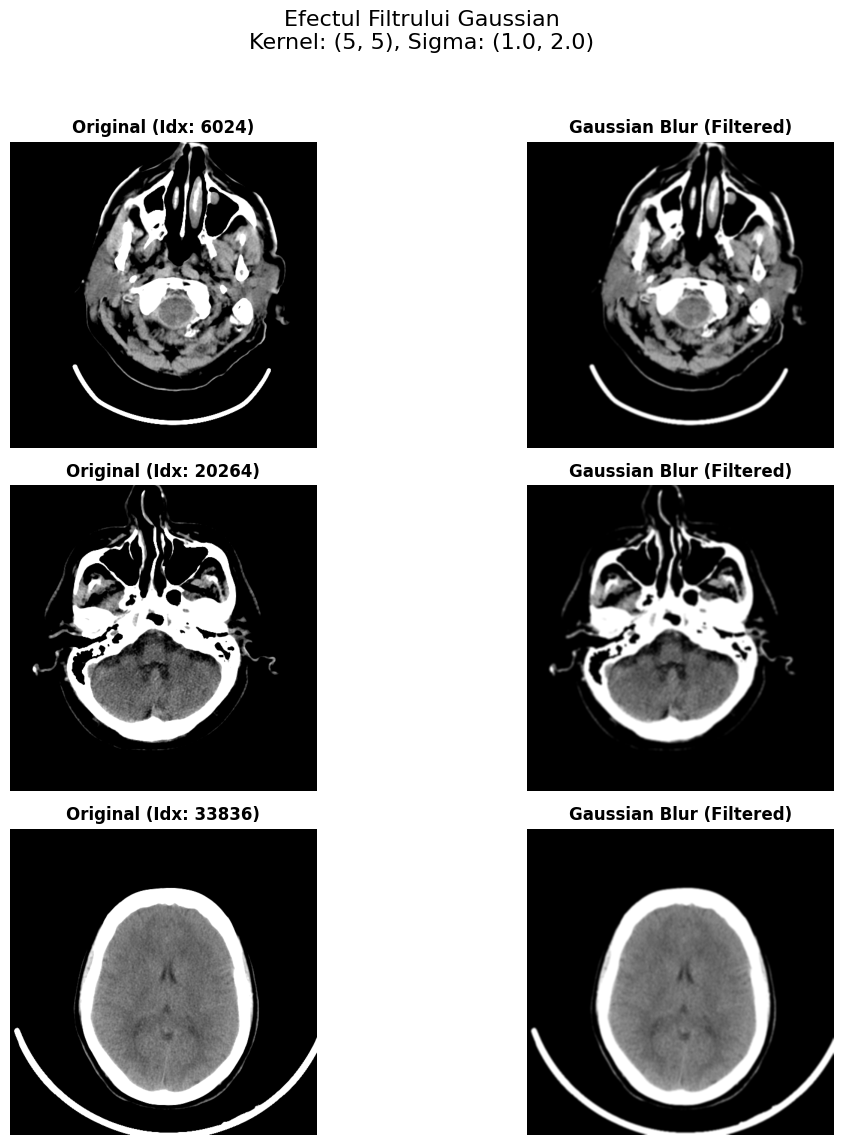

In [34]:
def visualize_gaussian_filter(dataset, kernel_size=(5, 5), sigma=(1.0, 2.0)):
    
    gaussian_transform = transforms.GaussianBlur(kernel_size=kernel_size, sigma=sigma)
    
    total_images = len(dataset)
    indices = random.sample(range(total_images), 3)
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    plt.suptitle(f"Efectul Filtrului Gaussian\nKernel: {kernel_size}, Sigma: {sigma}", fontsize=16)
    
    for i, idx in enumerate(indices):
        original_obj, _ = dataset[idx]
        
        transformed_obj = gaussian_transform(original_obj)
        
        def convert_to_numpy(img):
            if isinstance(img, torch.Tensor):
                arr = img.numpy()
                if arr.shape[0] == 1: return arr.squeeze()      # Grayscale
                if arr.shape[0] == 3: return np.transpose(arr, (1, 2, 0)) # RGB
            else:
                return np.array(img) # PIL -> Numpy direct

        img_orig_np = convert_to_numpy(original_obj)
        img_trans_np = convert_to_numpy(transformed_obj)
        
        cmap = 'gray' if len(img_orig_np.shape) == 2 else None
        
        ax_orig = axes[i, 0]
        ax_orig.imshow(img_orig_np, cmap=cmap)
        ax_orig.set_title(f"Original (Idx: {idx})", fontweight='bold')
        ax_orig.axis('off')
        
        ax_trans = axes[i, 1]
        ax_trans.imshow(img_trans_np, cmap=cmap)
        ax_trans.set_title(f"Gaussian Blur (Filtered)", fontweight='bold')
        ax_trans.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("gauss.png")
    plt.show()

visualize_gaussian_filter(full_train_dataset)

## CLAHE Filter - examples

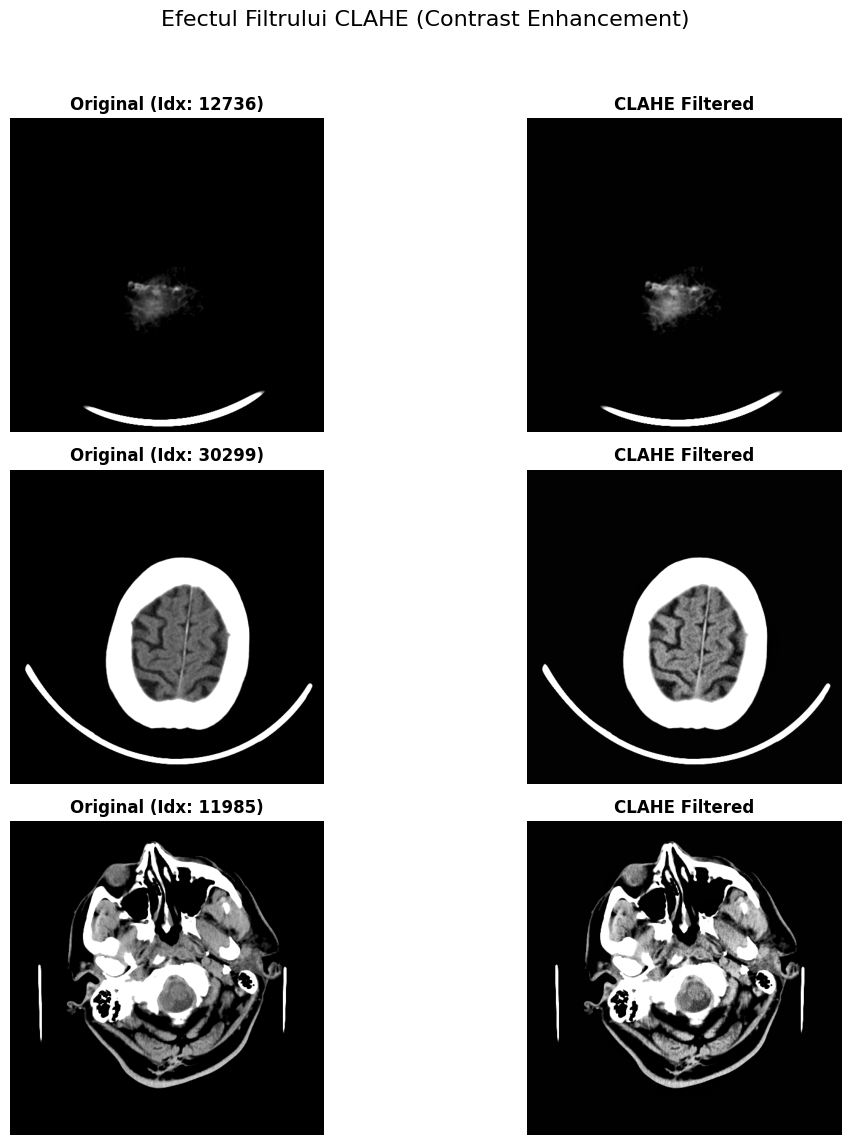

In [40]:
def visualize_clahe_filter(dataset):
    
    clahe = A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1)
    
    total_images = len(dataset)
    indices = random.sample(range(total_images), 3)
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    plt.suptitle(f"Efectul Filtrului CLAHE (Contrast Enhancement)", fontsize=16)
    
    for i, idx in enumerate(indices):
        img_obj, _ = dataset[idx]
        
        if isinstance(img_obj, torch.Tensor):
            img_np = img_obj.numpy()
            # Daca e Tensor (C, H, W), il facem (H, W, C) sau (H, W)
            if img_np.shape[0] == 1:
                img_np = img_np.squeeze()
            elif img_np.shape[0] == 3:
                img_np = np.transpose(img_np, (1, 2, 0))
        else:
            # Daca e PIL, il convertim direct in Numpy array
            img_np = np.array(img_obj)

        if img_np.dtype != np.uint8:
            if img_np.max() <= 1.0:
                img_np = (img_np * 255).astype(np.uint8)
            else:
                img_np = img_np.astype(np.uint8)

        transformed_dict = clahe(image=img_np)
        img_trans_np = transformed_dict['image']
        
        cmap = 'gray' if len(img_np.shape) == 2 else None
        
        ax_orig = axes[i, 0]
        ax_orig.imshow(img_np, cmap=cmap)
        ax_orig.set_title(f"Original (Idx: {idx})", fontweight='bold')
        ax_orig.axis('off')
        
        ax_trans = axes[i, 1]
        ax_trans.imshow(img_trans_np, cmap=cmap)
        ax_trans.set_title(f"CLAHE Filtered", fontweight='bold')
        ax_trans.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("clahe.png")
    plt.show()

visualize_clahe_filter(full_train_dataset)

### Augmentations - Examples

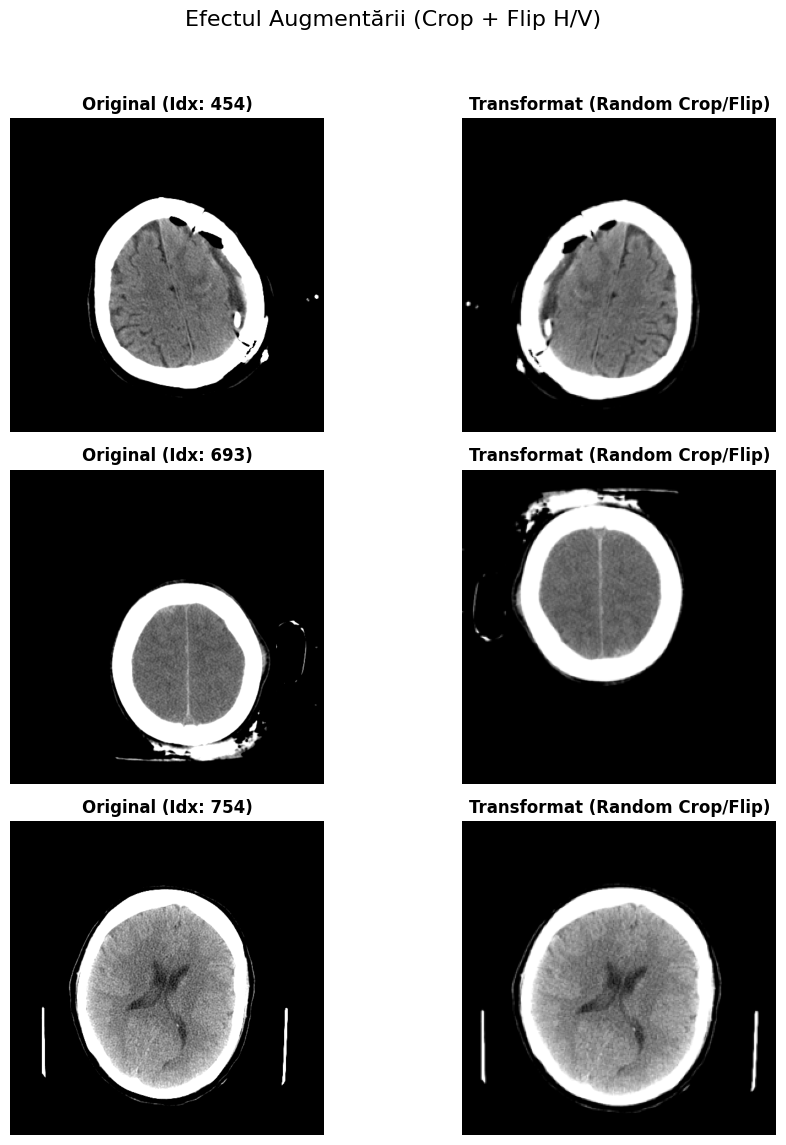

In [9]:
import matplotlib.pyplot as plt
import random
import torch
import numpy as np
from torchvision import transforms
from PIL import Image

def visualize_augmentations(dataset, subset_limit=1000, num_samples=3):
    
    aug_pipeline = transforms.Compose([
        transforms.RandomResizedCrop(size=(256, 256), scale=(0.85, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5)
    ])
    
    limit = min(len(dataset), subset_limit)
    indices = random.sample(range(limit), num_samples)
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    plt.suptitle(f"Efectul Augmentării (Crop + Flip H/V)", fontsize=16)
    
    for i, idx in enumerate(indices):
        row = dataset.data.iloc[idx]
        img_id = row['ImageID']
        img_filename = f"{img_id}_frame0.png"
        
        import os
        full_path = os.path.join(dataset.root_dir, img_filename)
        
        try:
            original_pil = Image.open(full_path).convert('L')
        except:
            original_pil = Image.new('L', (256, 256))

        augmented_pil = aug_pipeline(original_pil)
        
        
        orig_np = np.array(original_pil)
        aug_np = np.array(augmented_pil)
        
        ax_orig = axes[i, 0]
        ax_orig.imshow(orig_np, cmap='gray')
        ax_orig.set_title(f"Original (Idx: {idx})", fontweight='bold')
        ax_orig.axis('off')
        
        ax_aug = axes[i, 1]
        ax_aug.imshow(aug_np, cmap='gray')
        ax_aug.set_title(f"Transformat (Random Crop/Flip)", fontweight='bold')
        ax_aug.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("augmentations.png")
    plt.show()


visualize_augmentations(full_train_dataset, subset_limit=1000, num_samples=3)

### Applying transformations to images in dataset

In [6]:
# CLASA PENTRU APLICAREA FILTRULUI CLAHE CA TRANSFORMARE TORCH

class CustomCLAHE:
    
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        img_np = np.array(img)
        
        if len(img_np.shape) == 2: # Grayscale pur
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
            img_clahe = clahe.apply(img_np)
        else: # RGB 
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            
            clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
            l_clahe = clahe.apply(l)
            
            lab_clahe = cv2.merge((l_clahe, a, b))
            img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

        return Image.fromarray(img_clahe)

In [7]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=(256, 256), scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    CustomCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    CustomCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Task 7 - Implementing the neural network training pipeline

### Applying the transformations

In [8]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import numpy as np

TRAIN_CSV = '/kaggle/input/rsna-hemorrhage-detection-dataset/subdataset_train.csv'
TRAIN_IMG_DIR = '/kaggle/input/rsna-hemorrhage-detection-dataset/rsna-intracranial-hemorrhage-detection-png/train_images'

TEST_CSV = '/kaggle/input/rsna-hemorrhage-detection-dataset/subdataset_test.csv'
TEST_IMG_DIR = '/kaggle/input/rsna-hemorrhage-detection-dataset/rsna-intracranial-hemorrhage-detection-png/test_images'

temp_dataset = RSNADataset(csv_file=TRAIN_CSV, root_dir=TRAIN_IMG_DIR)
all_indices = np.arange(len(temp_dataset))

train_idx, val_idx = train_test_split(
    all_indices, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

print(f"Total imagini antrenare disponibile: {len(all_indices)}")
print(f"Index split: {len(train_idx)} train / {len(val_idx)} validation")

train_dataset_full = RSNADataset(
    csv_file=TRAIN_CSV,     
    root_dir=TRAIN_IMG_DIR, 
    transform=train_transforms 
)

val_dataset_full = RSNADataset(
    csv_file=TRAIN_CSV,      
    root_dir=TRAIN_IMG_DIR,  
    transform=test_transforms 
)

test_dataset = RSNADataset(
    csv_file=TEST_CSV, 
    root_dir=TEST_IMG_DIR, 
    transform=test_transforms
)

train_subset = Subset(train_dataset_full, train_idx)

val_subset = Subset(val_dataset_full, val_idx)

BATCH_SIZE = 16

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders create cu succes!")


try:
    sample_img, sample_lbl = next(iter(train_loader))
    print(f"Test DataLoader reușit: Batch shape {sample_img.shape}")
except Exception as e:
    print(f"EROARE la extragerea din DataLoader: {e}")

Total imagini antrenare disponibile: 40353
Index split: 32282 train / 8071 validation
DataLoaders create cu succes!
Test DataLoader reușit: Batch shape torch.Size([16, 1, 256, 256])


### Definition of the Neural Network (CNN)

In [ ]:
# '''This function can be useful in determining the output size of a convolutional layer in a neural network,
# given the input dimensions and the convolutional layer's parameters.'''

# def findConv2dOutShape(hin,win,conv,pool=2):
#     # get conv arguments
#     kernel_size = conv.kernel_size
#     stride=conv.stride
#     padding=conv.padding
#     dilation=conv.dilation

#     hout=np.floor((hin+2*padding[0]-dilation[0]*(kernel_size[0]-1)-1)/stride[0]+1)
#     wout=np.floor((win+2*padding[1]-dilation[1]*(kernel_size[1]-1)-1)/stride[1]+1)

#     if pool:
#         hout/=pool
#         wout/=pool
#     return int(hout),int(wout)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HemorrhageCNN(nn.Module):
    def __init__(self, num_classes=6, input_channels=1):
        
        super(HemorrhageCNN, self).__init__()
        
        # Input: (Batch, 1, 256, 256) -> Output: (Batch, 32, 256, 256)
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1)
        
        # Input: (Batch, 32, 128, 128) -> Output: (Batch, 64, 128, 128)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Input: (Batch, 64, 64, 64) -> Output: (Batch, 128, 64, 64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Input: (Batch, 128, 32, 32) -> Output: (Batch, 256, 32, 32)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        
        # MaxPool reduce dimensiunea la jumatate (2x2)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        # Daca intram cu 256x256 si facem 4 pooling-uri:
        # 256 -> 128 -> 64 -> 32 -> 16
        # Dimensiunea finala a imaginii este 16x16 pixeli, cu 256 canale.
        self.flatten_size = 256 * 16 * 16 
        
        self.fc1 = nn.Linear(self.flatten_size, 512)
        self.fc2 = nn.Linear(512, num_classes) # Output: 6 valori

    def forward(self, x):
        # Bloc 1
        x = F.relu(self.conv1(x))
        x = self.pool(x) # 256 -> 128
        
        # Bloc 2
        x = F.relu(self.conv2(x))
        x = self.pool(x) # 128 -> 64
        
        # Bloc 3
        x = F.relu(self.conv3(x))
        x = self.pool(x) # 64 -> 32
        
        # Bloc 4
        x = F.relu(self.conv4(x))
        x = self.pool(x) # 32 -> 16
        
        # Flatten
        x = x.view(-1, self.flatten_size)
        
        # Clasificator
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        # ATENTIE: Nu aplicam Softmax sau Sigmoid aici!
        # Returnam "logits" (valori brute) pentru a fi folosite cu BCEWithLogitsLoss
        return x

### Defining the loss function and optimizer

In [10]:
import torch.optim as optim

# Detectare GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiere model
model = HemorrhageCNN(num_classes=6, input_channels=1).to(device)

# Optimizator Adam
learning_rate = 0.0001
weight_decay = 1e-6  # Regularization term to prevent overfitting
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Loss function
pos_weight = torch.tensor([2.0, 2.0, 2.0, 2.0, 2.0, 2.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

### Training the model

In [11]:
import torch
import copy

class Trainer:
    def __init__(self, model, optimizer, criterion, device='cuda', log_interval=20):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.log_interval = log_interval
        self.metrics = {'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}
        
        self.best_val_loss = float('inf') # Initialize with infinity
        self.best_model_path = 'best_model.pth'

    def calculate_accuracy(self, outputs, labels):
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct_counts = (preds == labels).sum().item()
        total_counts = labels.numel()
        return correct_counts, total_counts

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0.0
        total_correct = 0
        total_elements = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            correct, num_elements = self.calculate_accuracy(outputs, labels)
            total_correct += correct
            total_elements += num_elements
            
            if (i + 1) % self.log_interval == 0:
                batch_loss = loss.item()
                batch_acc = correct / num_elements
                print(f"   Step [{i+1}/{len(train_loader)}] | Batch Loss: {batch_loss:.4f} | Batch Acc: {batch_acc:.4f}")

        epoch_loss = total_loss / len(train_loader)
        epoch_accuracy = total_correct / total_elements
        return epoch_loss, epoch_accuracy

    def evaluate(self, val_loader):
        self.model.eval()
        total_loss = 0.0
        total_correct = 0
        total_elements = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                correct, num_elements = self.calculate_accuracy(outputs, labels)
                total_correct += correct
                total_elements += num_elements

        epoch_loss = total_loss / len(val_loader)
        epoch_accuracy = total_correct / total_elements
        return epoch_loss, epoch_accuracy

    def train(self, train_loader, val_loader, num_epochs=25):
        print(f"Starting training on device: {self.device}")
        
        for epoch in range(num_epochs):
            print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")
            
            train_loss, train_accuracy = self.train_epoch(train_loader)
            val_loss, val_accuracy = self.evaluate(val_loader)

            print(f'Epoch {epoch + 1} Summary => '
                  f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

            # Save metrics
            self.metrics['train_loss'].append(train_loss)
            self.metrics['train_accuracy'].append(train_accuracy)
            self.metrics['val_loss'].append(val_loss)
            self.metrics['val_accuracy'].append(val_accuracy)
            
            # We want to minimize Loss, so we check if current val_loss is lower than best
            if val_loss < self.best_val_loss:
                print(f"   [+] Validation Loss improved from {self.best_val_loss:.4f} to {val_loss:.4f}. Saving model...")
                self.best_val_loss = val_loss
                torch.save(self.model.state_dict(), self.best_model_path)
            else:
                print(f"   [-] Validation Loss did not improve (Best: {self.best_val_loss:.4f})")

    def get_metrics(self):
        return self.metrics

In [12]:
trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, device=device)

trainer.train(train_loader, val_loader)
metrics = trainer.get_metrics()

Starting training on device: cuda

--- Epoch 1/25 ---
   Step [20/2018] | Batch Loss: 0.6344 | Batch Acc: 0.8125
   Step [40/2018] | Batch Loss: 0.5876 | Batch Acc: 0.8438
   Step [60/2018] | Batch Loss: 0.6873 | Batch Acc: 0.8229
   Step [80/2018] | Batch Loss: 0.5153 | Batch Acc: 0.8750
   Step [100/2018] | Batch Loss: 0.7873 | Batch Acc: 0.7708
   Step [120/2018] | Batch Loss: 0.7883 | Batch Acc: 0.7083
   Step [140/2018] | Batch Loss: 0.4899 | Batch Acc: 0.8750
   Step [160/2018] | Batch Loss: 0.5236 | Batch Acc: 0.8750
   Step [180/2018] | Batch Loss: 0.3501 | Batch Acc: 0.9167
   Step [200/2018] | Batch Loss: 0.6343 | Batch Acc: 0.8229
   Step [220/2018] | Batch Loss: 0.3647 | Batch Acc: 0.9062
   Step [240/2018] | Batch Loss: 0.4523 | Batch Acc: 0.8646
   Step [260/2018] | Batch Loss: 0.6909 | Batch Acc: 0.8021
   Step [280/2018] | Batch Loss: 0.3809 | Batch Acc: 0.9062
   Step [300/2018] | Batch Loss: 0.4933 | Batch Acc: 0.8646
   Step [320/2018] | Batch Loss: 0.4295 | Batch Ac

### Analysing the results

In [13]:
def plot_metrics(metrics):
    epochs = range(1, len(metrics['train_loss']) + 1)

    # Plot training and validation loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics['train_loss'], label='Train Loss')
    plt.plot(epochs, metrics['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics['train_accuracy'], label='Train Accuracy')
    plt.plot(epochs, metrics['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

Val Accuracy (Label-wise): 90.75%


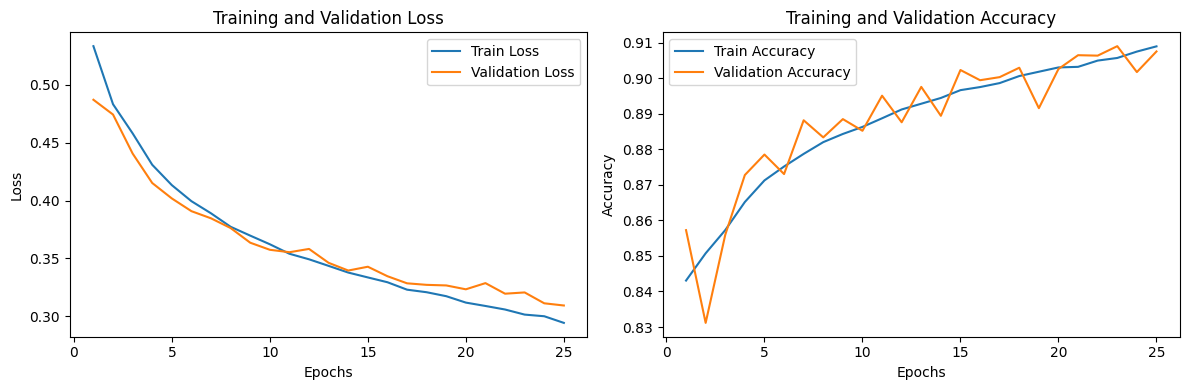

In [14]:
# Test on Validation Set
correct_predictions = 0
total_elements = 0  

model.eval() 

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        
        probs = torch.sigmoid(outputs)
        
        predicted = (probs > 0.5).float()
        
        correct_predictions += (predicted == labels).sum().item()
        
        total_elements += labels.numel()

accuracy = correct_predictions / total_elements
print(f'Val Accuracy (Label-wise): {accuracy * 100:.2f}%')

plot_metrics(metrics)

### Running the model on the test dataset

In [15]:
def plot_confusion_matrices(cms, class_names):
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, (cm, name) in enumerate(zip(cms, class_names)):
        
        labels = ['Negativ (Sanatos)', 'Pozitiv (Bolnav)']
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
        
        axes[i].set_title(f"Matrice Confuzie: {name}", fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Eticheta Reala')
        axes[i].set_xlabel('Predictia Modelului')
        
    plt.tight_layout()
    plt.show()

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, multilabel_confusion_matrix, classification_report

def evaluate_model_on_test(model, test_loader, device, threshold=0.5):
    # model.eval()
    all_targets = []
    all_predictions = []
    
    print("Generare predictii pe setul de test...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            outputs = model(images)
            
            probs = torch.sigmoid(outputs)
            
            preds = (probs > threshold).float()
            
            all_targets.append(labels.cpu().numpy())
            all_predictions.append(preds.cpu().numpy())
    
    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_predictions)
    
    class_names = ['Epidural', 'Intraparenchymal', 'Intraventricular', 'Subarachnoid', 'Subdural', 'Any']
    
    print("\n" + "="*60)
    print("REZULTATE EVALUARE FINALA")
    print("="*60)
    
    subset_acc = accuracy_score(y_true, y_pred)
    print(f"Exact Match Accuracy (Subset): {subset_acc:.4f}")
    
    hamming_acc = (y_true == y_pred).mean()
    print(f"Label-wise Accuracy:         {hamming_acc:.4f}")
    
    print("\n--- Raport Detaliat pe Clase ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    
    # Plotarea matricilor
    plot_confusion_matrices(mcm, class_names)

S-a incarcat cel mai bun model salvat!
Generare predictii pe setul de test...

REZULTATE EVALUARE FINALA
Exact Match Accuracy (Subset): 0.3019
Label-wise Accuracy:         0.8153

--- Raport Detaliat pe Clase ---
                  precision    recall  f1-score   support

        Epidural       0.10      0.52      0.17       123
Intraparenchymal       0.75      0.73      0.74      3463
Intraventricular       0.73      0.82      0.77      3011
    Subarachnoid       0.58      0.61      0.59      3292
        Subdural       0.69      0.54      0.61      3170
             Any       0.99      0.88      0.93      8034

       micro avg       0.77      0.75      0.76     21093
       macro avg       0.64      0.68      0.63     21093
    weighted avg       0.80      0.75      0.77     21093
     samples avg       0.65      0.66      0.63     21093



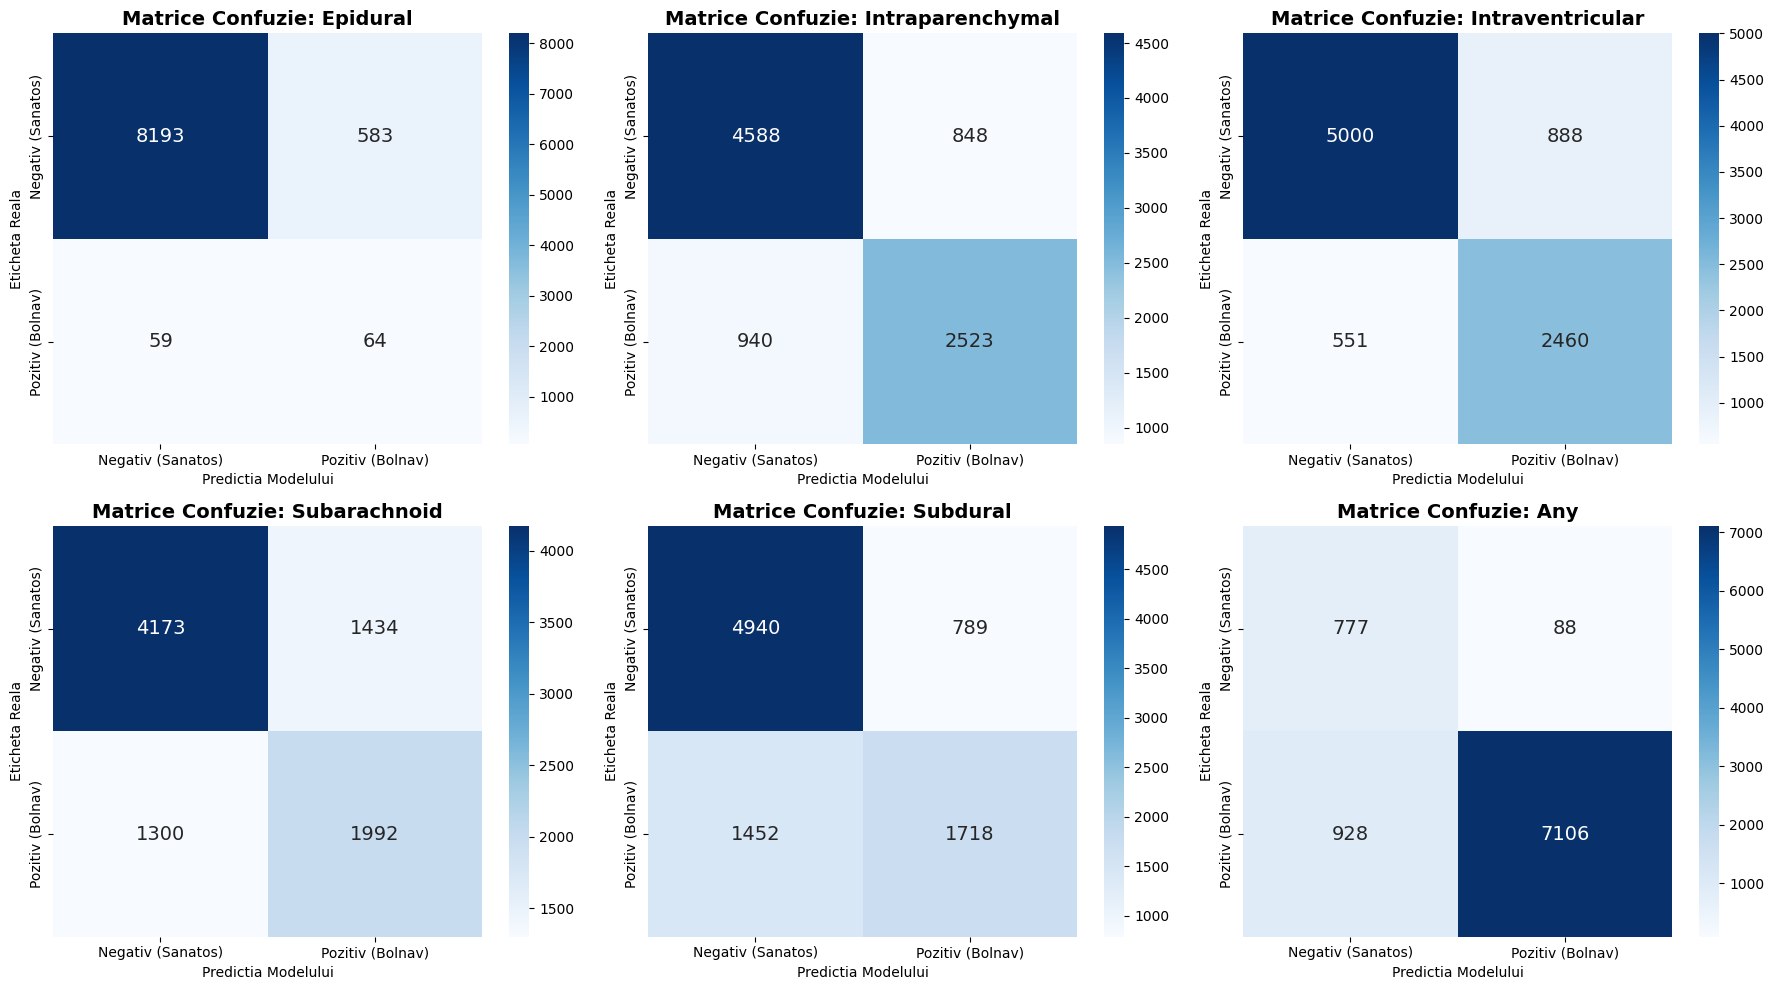

In [21]:
try:
    model.load_state_dict(torch.load('best_model.pth'))
    print("S-a incarcat cel mai bun model salvat!")
except:
    print("Atentie: Se foloseste modelul curent din memorie (posibil ultima epoca, nu cea mai buna).")

# 3. Ruleaza Evaluarea
evaluate_model_on_test(model, test_loader, device)